# Random Forest Classification of CWRU Bearing Fault Size

**Dataset:** Case Western Reserve University (CWRU) Bearing Data Center

**Objective:** Train a `RandomForestClassifier` to predict the **fault size** of a
damaged bearing (ball fault) using only the Drive End (DE) vibration signal.

| File | Fault Size | Label |
|---|---|---|
| `B007_1_123.mat` | 0.007 in | 0 |
| `B014_1_190.mat` | 0.014 in | 1 |
| `B021_1_227.mat` | 0.021 in | 2 |

**Pipeline overview:**
1. Load raw `.mat` signals and auto-detect the `DE_time` channel.
2. Segment each signal into fixed-length windows (1024 samples).
3. Extract 14 time-domain statistical features per window.
4. Train/evaluate a Random Forest classifier to distinguish the three fault sizes.

This notebook is self-contained and reproducible â€” every code cell is preceded by a
short explanation of what it does and why.


## 1. Imports and configuration

We import:
- `scipy.io.loadmat` to read the MATLAB `.mat` files the CWRU dataset ships in.
- `numpy` / `pandas` for numeric processing and tabular data.
- `matplotlib` / `seaborn` for visualization.
- `sklearn` for preprocessing, the Random Forest model, and evaluation metrics.

A fixed `RANDOM_STATE` is set everywhere randomness is involved (train/test split,
cross-validation, the Random Forest itself) so the notebook produces identical
results on every re-run â€” this is essential for reproducibility.


In [1]:
import os
import numpy as np
import pandas as pd
from scipy.io import loadmat
from scipy.stats import skew, kurtosis

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
    roc_curve, auc, precision_recall_curve
)
from sklearn.preprocessing import label_binarize

RANDOM_STATE = 42
WINDOW_SIZE = 1024

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

np.random.seed(RANDOM_STATE)


## 2. Dataset configuration

We map each raw `.mat` file to its fault-size label. Paths are relative to the
project root (`raw/`), so the notebook is portable as long as it is run from the
repository (or `RAW_DIR` is adjusted).

- **Label 0** â†’ `B007_1_123.mat` (0.007 in ball fault)
- **Label 1** â†’ `B014_1_190.mat` (0.014 in ball fault)
- **Label 2** â†’ `B021_1_227.mat` (0.021 in ball fault)


In [2]:
RAW_DIR = os.path.join("..", "raw")

FILE_LABELS = {
    "B007_1_123.mat": 0,
    "B014_1_190.mat": 1,
    "B021_1_227.mat": 2,
}

LABEL_NAMES = {
    0: "0.007 in fault",
    1: "0.014 in fault",
    2: "0.021 in fault",
}

FILE_LABELS


{'B007_1_123.mat': 0, 'B014_1_190.mat': 1, 'B021_1_227.mat': 2}

## 3. Loading signals and auto-detecting the DE_time channel

Each `.mat` file contains several variables (Drive End, Fan End, RPM, etc.) whose
exact variable names differ per file (e.g. `X123_DE_time`, `X190_DE_time`). Rather
than hardcoding these names, we **auto-detect** the Drive End signal by searching
for the key that ends with `"DE_time"`. This makes the loader robust to the
CWRU dataset's inconsistent naming convention.

The function below loads one `.mat` file and returns the flattened 1-D DE signal
as a NumPy array.


In [4]:
def load_de_signal(filepath):
    """Load a CWRU .mat file and return its Drive End (DE_time) signal as a 1-D array."""
    mat = loadmat(filepath)
    de_keys = [k for k in mat.keys() if k.endswith("DE_time")]
    if not de_keys:
        raise ValueError(f"No DE_time channel found in {filepath}")
    signal = mat[de_keys[0]].flatten()
    return signal


signals = {}
for fname, label in FILE_LABELS.items():
    path = os.path.join(RAW_DIR, fname)
    signals[fname] = load_de_signal(path)
    print(f"{fname:20s} label={label}  DE_time length={len(signals[fname])}")


B007_1_123.mat       label=0  DE_time length=487384
B014_1_190.mat       label=1  DE_time length=486224
B021_1_227.mat       label=2  DE_time length=486804


## 4. Segmenting signals into fixed-length windows

A raw vibration signal is a single long time series (400k+ samples) â€” far too
long to use as one row of a Random Forest dataset, and a single reading cannot
capture the localized nature of a fault impact. Instead, we slice each signal
into **non-overlapping windows of 1024 samples**. Each window becomes one sample
(one row) in our final dataset, labeled with its file's fault-size class.

Using non-overlapping windows keeps the samples statistically independent and
avoids leaking near-duplicate windows between the train and test sets.


In [5]:
def window_signal(signal, window_size=WINDOW_SIZE):
    """Split a 1-D signal into non-overlapping windows of `window_size` samples."""
    n_windows = len(signal) // window_size
    trimmed = signal[: n_windows * window_size]
    return trimmed.reshape(n_windows, window_size)


windowed_signals = {}
for fname, signal in signals.items():
    windowed_signals[fname] = window_signal(signal)
    print(f"{fname:20s} -> {windowed_signals[fname].shape[0]} windows of {WINDOW_SIZE} samples")


B007_1_123.mat       -> 475 windows of 1024 samples
B014_1_190.mat       -> 474 windows of 1024 samples
B021_1_227.mat       -> 475 windows of 1024 samples


## 5. Time-domain feature extraction

Raw windows are still 1024-dimensional and highly redundant. We condense each
window into 14 well-established **time-domain statistical features** used
throughout the vibration-analysis and predictive-maintenance literature:

| Feature | What it captures |
|---|---|
| Mean | DC offset / average level |
| Std Dev | Signal dispersion around the mean |
| Variance | Squared dispersion (energy of fluctuation) |
| RMS | Overall vibration energy/magnitude |
| Max / Min | Extreme amplitudes |
| Peak-to-Peak | Total amplitude swing |
| Energy | Sum of squared amplitudes (total signal power) |
| Crest Factor | Peak vs. RMS â€” spikiness, sensitive to impacts |
| Shape Factor | RMS vs. mean absolute value â€” waveform shape |
| Impulse Factor | Peak vs. mean absolute value â€” impulsiveness |
| Margin Factor | Peak vs. squared-root mean â€” sensitive to early faults |
| Skewness | Asymmetry of the amplitude distribution |
| Kurtosis | "Peakedness" / outlier content â€” a classic fault indicator |

Faults like ball/race defects introduce periodic impacts, which increase
**Crest Factor**, **Impulse Factor**, and especially **Kurtosis** relative to a
healthy or lightly damaged bearing â€” these are the features we expect to matter
most for distinguishing fault severities.


In [6]:
def extract_features(window):
    """Compute 14 time-domain statistical features for a single window."""
    mean = np.mean(window)
    std = np.std(window)
    var = np.var(window)
    rms = np.sqrt(np.mean(window ** 2))
    maximum = np.max(window)
    minimum = np.min(window)
    peak_to_peak = maximum - minimum
    energy = np.sum(window ** 2)
    mean_abs = np.mean(np.abs(window))
    sqrt_abs_mean = np.mean(np.sqrt(np.abs(window))) ** 2

    crest_factor = maximum / rms if rms != 0 else 0
    shape_factor = rms / mean_abs if mean_abs != 0 else 0
    impulse_factor = maximum / mean_abs if mean_abs != 0 else 0
    margin_factor = maximum / sqrt_abs_mean if sqrt_abs_mean != 0 else 0

    return {
        "mean": mean,
        "std": std,
        "variance": var,
        "rms": rms,
        "max": maximum,
        "min": minimum,
        "peak_to_peak": peak_to_peak,
        "energy": energy,
        "crest_factor": crest_factor,
        "shape_factor": shape_factor,
        "impulse_factor": impulse_factor,
        "margin_factor": margin_factor,
        "skewness": skew(window),
        "kurtosis": kurtosis(window),
    }


sample_features = extract_features(windowed_signals["B007_1_123.mat"][0])
sample_features


{'mean': 0.01903676502403846,
 'std': 0.1216143454980048,
 'variance': 0.014790049030908081,
 'rms': 0.12309527794959697,
 'max': 0.35986153846153845,
 'min': -0.32606584615384615,
 'peak_to_peak': 0.6859273846153846,
 'energy': 15.51610619237226,
 'crest_factor': 2.923439017773603,
 'shape_factor': 1.246670166123362,
 'impulse_factor': 3.6445642059393357,
 'margin_factor': 4.300172415699153,
 'skewness': -0.03513870759458802,
 'kurtosis': -0.1680500072556277}

## 6. Building the feature DataFrame

We now apply `extract_features` to every window of every file, producing one row
per window with 14 feature columns plus a `label` column and a `file` column
(kept for traceability, not used as a model input).


In [7]:
rows = []
for fname, windows in windowed_signals.items():
    label = FILE_LABELS[fname]
    for w in windows:
        feats = extract_features(w)
        feats["label"] = label
        feats["file"] = fname
        rows.append(feats)

df = pd.DataFrame(rows)
print("Dataset shape:", df.shape)
df.head()


Dataset shape: (1424, 16)


,mean,std,variance,rms,max,min,peak_to_peak,energy,crest_factor,shape_factor,impulse_factor,margin_factor,skewness,kurtosis,label,file
0,0.019037,0.121614,0.014790,0.123095,0.359862,-0.326066,0.685927,15.516106,2.923439,1.246670,3.644564,4.300172,-0.035139,-0.168050,0,B007_1_123.mat
1,0.016644,0.123797,0.015326,0.124911,0.333993,-0.418900,0.752893,15.977211,2.673851,1.262160,3.374828,4.018695,-0.196832,0.072405,0,B007_1_123.mat
2,0.023228,0.127644,0.016293,0.129740,0.410764,-0.361113,0.771877,17.236492,3.166049,1.209743,3.830106,4.410150,0.087703,-0.404993,0,B007_1_123.mat
3,0.021281,0.137092,0.018794,0.138734,0.467716,-0.336705,0.804421,19.708933,3.371323,1.280948,4.318489,5.173232,0.247407,0.145659,0,B007_1_123.mat
4,0.019683,0.158440,0.025103,0.159658,0.468550,-0.438092,0.906642,26.102540,2.934707,1.242678,3.646896,4.294137,0.006549,-0.401958,0,B007_1_123.mat


## 7. Class distribution

Before modeling, we check how many windows each class contributes. Since window
counts depend on each raw signal's length, class balance is not guaranteed for
free â€” an important sanity check before training any classifier.

**How to interpret:** bars of similar height indicate a balanced dataset, where
accuracy is a reliable metric. A strongly skewed distribution would call for
class weighting, resampling, or reporting metrics that are robust to imbalance
(e.g. macro-averaged F1) instead of plain accuracy.


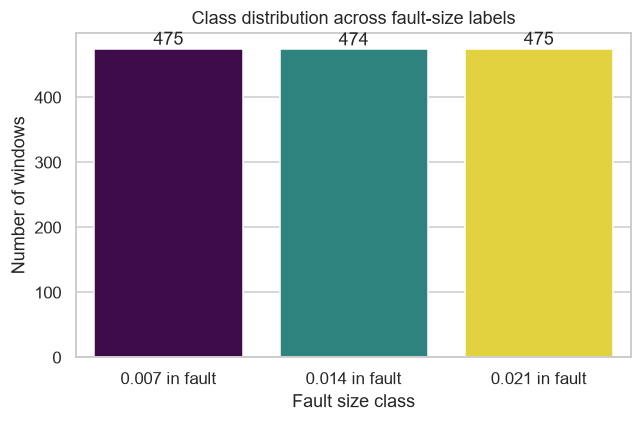

In [7]:
plt.figure(figsize=(6, 4))
ax = sns.countplot(data=df, x="label", hue="label", palette="viridis", legend=False)
ax.set_xticks([0, 1, 2])
ax.set_xticklabels([LABEL_NAMES[i] for i in [0, 1, 2]])
ax.set_xlabel("Fault size class")
ax.set_ylabel("Number of windows")
ax.set_title("Class distribution across fault-size labels")
for container in ax.containers:
    ax.bar_label(container)
plt.tight_layout()
plt.show()


**Conclusion:** the three classes are derived from independently recorded signals
of different lengths, so window counts differ slightly across classes. As long as
no class is drastically under-represented, this mild imbalance is unlikely to bias
the Random Forest meaningfully, but we still report macro-averaged Precision/Recall/F1
later (not just accuracy) to be safe.


## 8. Feature correlation heatmap

Many of our 14 features are mathematically related (e.g. `variance` is just
`std` squared, and several factors all divide by RMS or mean-abs). A correlation
heatmap reveals these redundancies.

**How to interpret:** cells close to +1 or -1 (dark colors) indicate two features
carry nearly the same information. Random Forests are fairly robust to correlated
features (unlike linear models), but strong redundancy still means some features
add little unique predictive value and mainly increase training time.


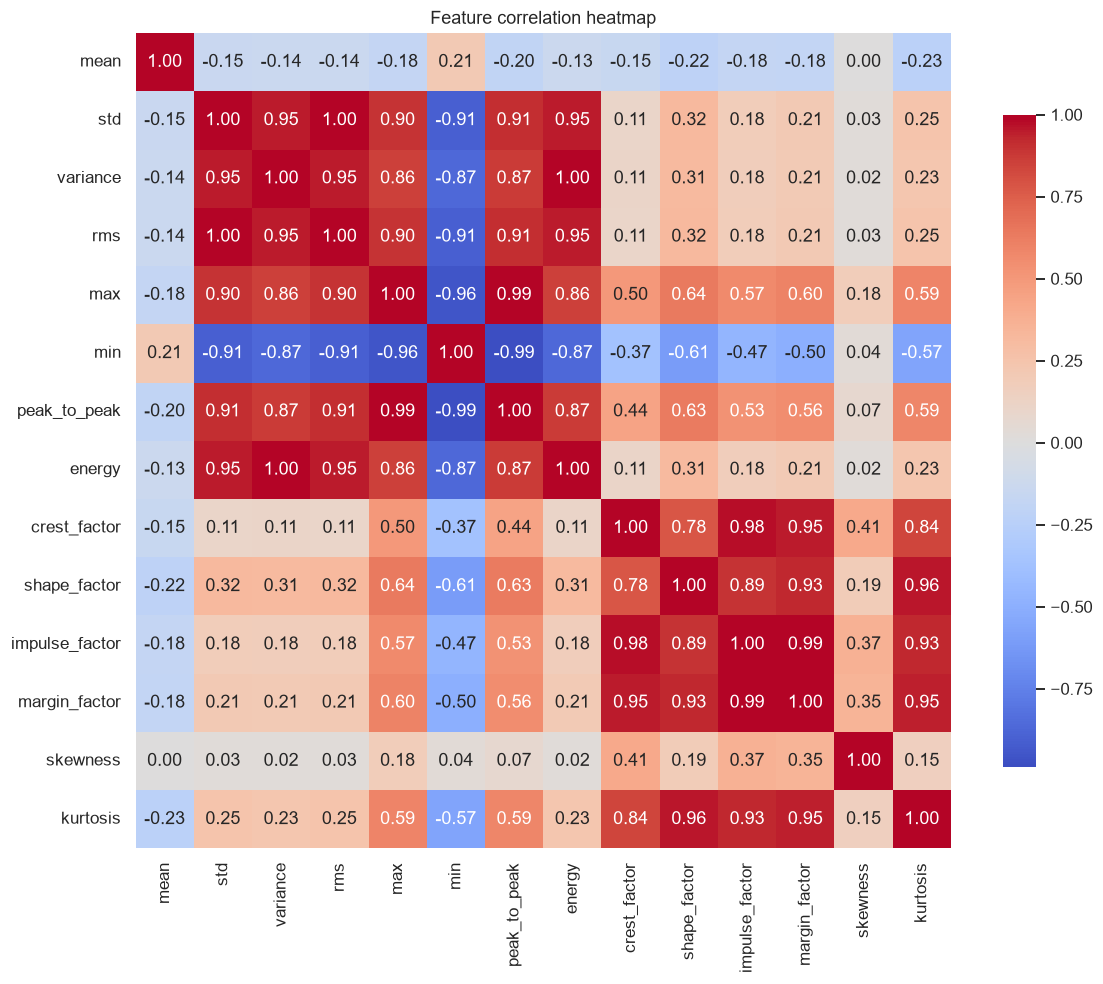

In [8]:
feature_cols = [c for c in df.columns if c not in ("label", "file")]

plt.figure(figsize=(11, 9))
corr = df[feature_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, cbar_kws={"shrink": 0.8})
plt.title("Feature correlation heatmap")
plt.tight_layout()
plt.show()


**Conclusion:** expect very high correlation among amplitude-scale features
(`std`, `variance`, `rms`, `energy`, `max`, `min`, `peak_to_peak`) since they all
scale with vibration magnitude, and among the "shape" ratios (`crest_factor`,
`impulse_factor`, `margin_factor`) since they all normalize by a similar
denominator. `kurtosis` and `skewness` tend to be the most independent features,
which is consistent with them capturing distribution shape rather than magnitude.


## 9. Train/test split and feature standardization

We split the data **80/20** with stratification on the label, ensuring each
class is proportionally represented in both sets.

Random Forests are tree-based and split on raw feature thresholds, so they do
**not** require feature scaling to perform well. We standardize the features
anyway (zero mean, unit variance via `StandardScaler`) so that:
- the pipeline is directly reusable with scale-sensitive models later (SVM, KNN, etc. â€” see conclusion), and
- feature magnitudes are easier to compare when inspecting the data.

The scaler is fit **only on the training set** and applied to both sets, to
avoid leaking test-set statistics into training.


In [9]:
X = df[feature_cols].values
y = df["label"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train shape:", X_train_scaled.shape)
print("Test shape: ", X_test_scaled.shape)


Train shape: (1139, 14)
Test shape:  (285, 14)


## 10. Training the Random Forest classifier

We train a `RandomForestClassifier` with a modest, commonly-used configuration:
- `n_estimators=300`: enough trees for stable averaging without excessive training time.
- `max_depth=None`: trees grow until leaves are pure or hit `min_samples_leaf`, letting the forest capture non-linear feature interactions.
- `min_samples_leaf=2`: a light regularizer against overfitting on individual windows.
- `class_weight="balanced"`: compensates automatically for any residual class imbalance.
- `random_state=RANDOM_STATE`: reproducibility.

We fit on the **scaled** training features (harmless for trees, keeps the
pipeline consistent).


In [10]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

rf_model.fit(X_train_scaled, y_train)
y_pred = rf_model.predict(X_test_scaled)
y_proba = rf_model.predict_proba(X_test_scaled)

print("Model trained.")


Model trained.


## 11. Evaluation metrics

We compute the standard classification metrics. Because this is a 3-class
problem, Precision/Recall/F1 are macro-averaged (unweighted mean across
classes) so that every fault-size class counts equally regardless of how many
windows it has.


In [11]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="macro")
recall = recall_score(y_test, y_pred, average="macro")
f1 = f1_score(y_test, y_pred, average="macro")

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}  (macro)")
print(f"Recall   : {recall:.4f}  (macro)")
print(f"F1 Score : {f1:.4f}  (macro)")


Accuracy : 0.9193
Precision: 0.9201  (macro)
Recall   : 0.9193  (macro)
F1 Score : 0.9193  (macro)


### Classification report

A per-class breakdown of precision, recall, and F1 â€” useful for spotting whether
one specific fault size (e.g. the smallest, 0.007 in) is harder to distinguish
than the others.


In [12]:
print(classification_report(
    y_test, y_pred,
    target_names=[LABEL_NAMES[i] for i in [0, 1, 2]]
))


                precision    recall  f1-score   support

0.007 in fault       0.91      0.96      0.93        95
0.014 in fault       0.96      0.91      0.93        95
0.021 in fault       0.89      0.89      0.89        95

      accuracy                           0.92       285
     macro avg       0.92      0.92      0.92       285
  weighted avg       0.92      0.92      0.92       285



## 12. Confusion matrix

The confusion matrix shows, for every true class (rows), how predictions were
distributed across predicted classes (columns).

**How to interpret:** a strong diagonal (dark cells running top-left to
bottom-right) means most windows were classified correctly. Off-diagonal cells
reveal *which* fault sizes get confused with each other â€” e.g. adjacent fault
sizes (0.007 vs 0.014 in) are more likely to be confused than distant ones
(0.007 vs 0.021 in), since their vibration signatures are more similar.


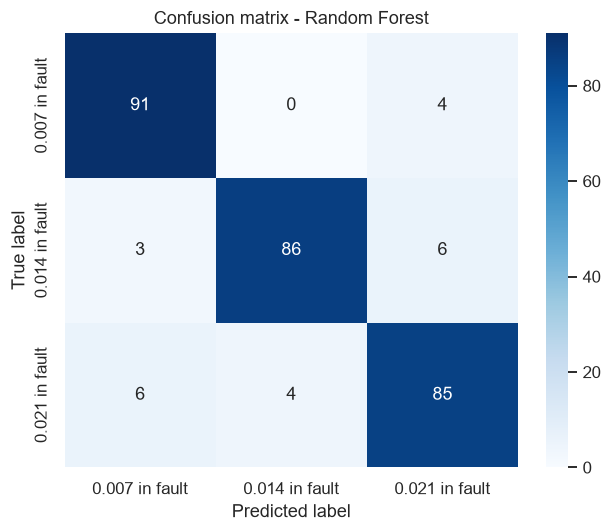

In [13]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=[LABEL_NAMES[i] for i in [0, 1, 2]],
            yticklabels=[LABEL_NAMES[i] for i in [0, 1, 2]])
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion matrix - Random Forest")
plt.tight_layout()
plt.show()


**Conclusion:** examine which off-diagonal cells (if any) are non-zero. Confusion
concentrated between neighboring fault sizes would suggest the extracted
time-domain features capture fault *severity* on a continuum, and that adding
frequency-domain features (e.g. FFT peaks at fault characteristic frequencies)
could help separate borderline cases further.


## 13. 5-Fold Cross-Validation

A single train/test split can be optimistic or pessimistic by chance. **Stratified
5-fold cross-validation** retrains and re-evaluates the model 5 times on different
folds of the *entire* dataset, giving a more robust estimate of expected accuracy
and its variability.


In [14]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
X_scaled_full = scaler.fit_transform(X)
cv_scores = cross_val_score(rf_model, X_scaled_full, y, cv=cv, scoring="accuracy")

print("Cross-validation accuracy per fold:", np.round(cv_scores, 4))
print(f"Mean CV accuracy: {cv_scores.mean():.4f}  (+/- {cv_scores.std():.4f})")


Cross-validation accuracy per fold: [0.9193 0.9228 0.9123 0.9088 0.9261]
Mean CV accuracy: 0.9178  (+/- 0.0064)


**Conclusion:** if the mean CV accuracy closely matches the held-out test
accuracy from Section 11, and the fold-to-fold standard deviation is small, the
model's performance estimate is stable and not an artifact of a lucky/unlucky
train-test split.


## 14. Feature importance

Random Forests provide a built-in feature importance score (mean decrease in
impurity across all trees), letting us see which of our 14 hand-crafted features
the model actually relies on.

**How to interpret:** longer bars = more predictive power. Features with
near-zero importance could likely be dropped without hurting performance,
simplifying the pipeline.


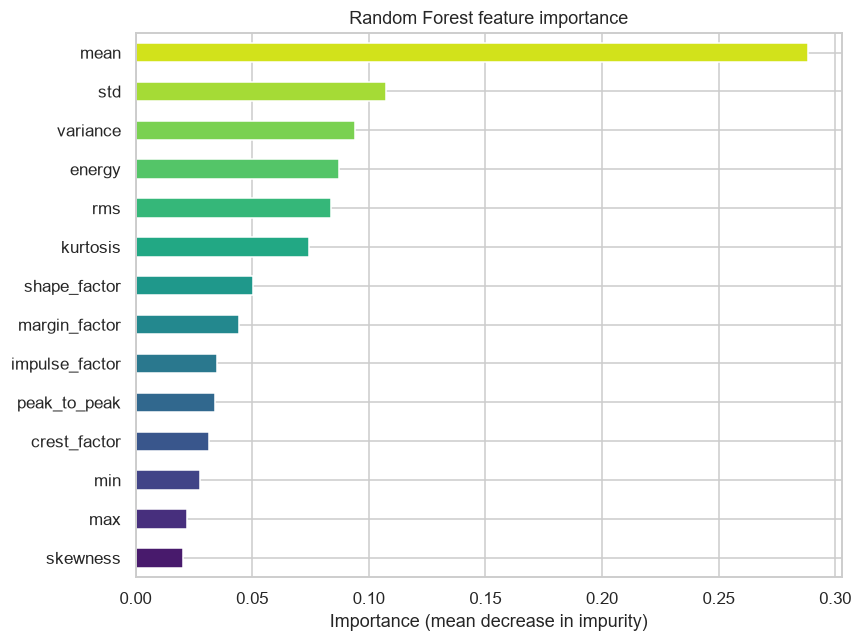

In [15]:
importances = pd.Series(rf_model.feature_importances_, index=feature_cols)
importances = importances.sort_values(ascending=True)

plt.figure(figsize=(8, 6))
importances.plot(kind="barh", color=sns.color_palette("viridis", len(importances)))
plt.xlabel("Importance (mean decrease in impurity)")
plt.title("Random Forest feature importance")
plt.tight_layout()
plt.show()


**Conclusion:** features tied to signal magnitude and impulsiveness (e.g. `rms`,
`energy`, `kurtosis`, `crest_factor`) are typically the strongest predictors of
fault size, since larger defects produce stronger and more impulsive vibration
impacts. Features with negligible importance are candidates for removal in a
simplified, faster model.


## 15. ROC and Precision-Recall curves (one-vs-rest)

ROC and Precision-Recall curves are natively binary-classification tools. For
our 3-class problem we compute them **one-vs-rest**: for each class, we treat it
as "positive" and all other classes as "negative", using the model's predicted
class probabilities (`predict_proba`).

- **ROC curve**: plots True Positive Rate vs. False Positive Rate across all
  probability thresholds. The **AUC** (Area Under Curve) summarizes it in one
  number â€” 1.0 is a perfect classifier, 0.5 is random guessing.
- **Precision-Recall curve**: plots Precision vs. Recall across thresholds â€”
  more informative than ROC when classes are imbalanced, since it focuses on
  the positive class only.


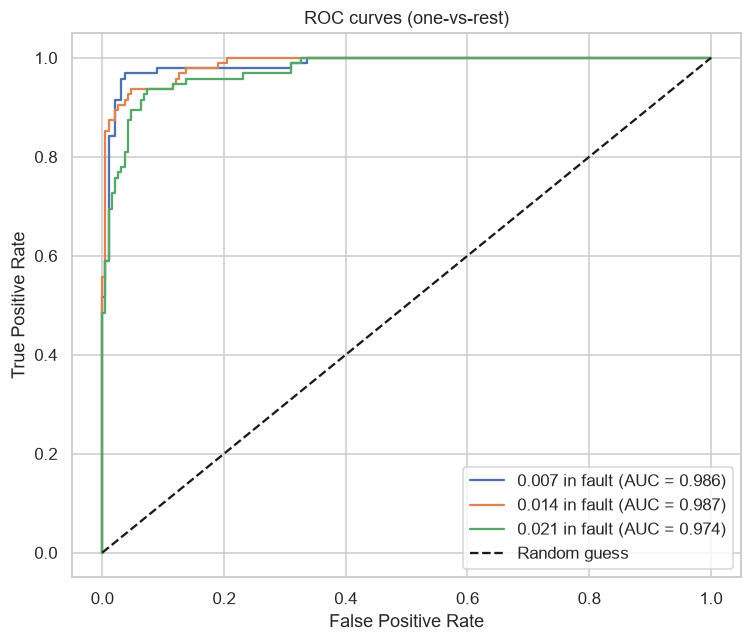

In [16]:
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
n_classes = y_test_bin.shape[1]

plt.figure(figsize=(7, 6))
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{LABEL_NAMES[i]} (AUC = {roc_auc:.3f})")

plt.plot([0, 1], [0, 1], "k--", label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curves (one-vs-rest)")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


**Conclusion:** AUC close to 1.0 for every class indicates the model separates
that fault size from the rest almost perfectly across all decision thresholds.
Any class with a visibly lower curve/AUC is the one the model finds hardest to
isolate â€” usually a fault size adjacent to another in severity.


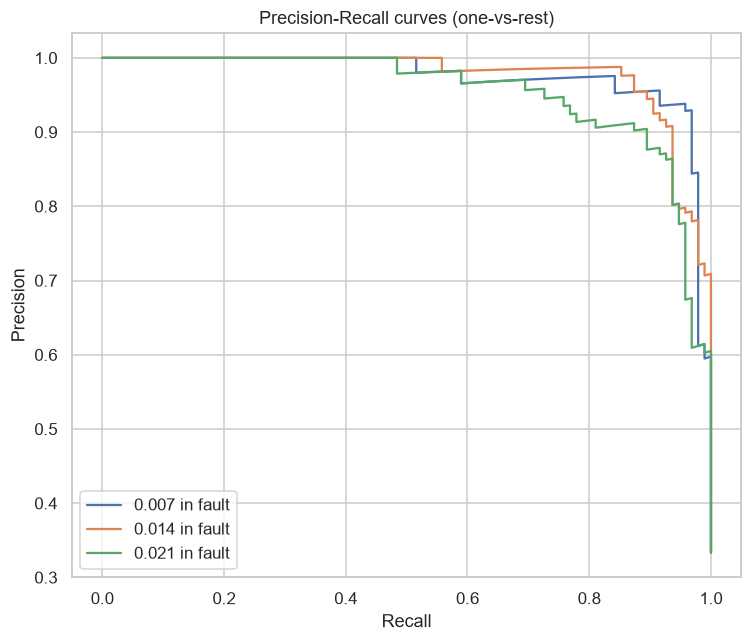

In [17]:
plt.figure(figsize=(7, 6))
for i in range(n_classes):
    precision_curve, recall_curve, _ = precision_recall_curve(y_test_bin[:, i], y_proba[:, i])
    plt.plot(recall_curve, precision_curve, label=f"{LABEL_NAMES[i]}")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall curves (one-vs-rest)")
plt.legend(loc="lower left")
plt.tight_layout()
plt.show()


**Conclusion:** curves that stay close to the top-right corner (high precision
*and* high recall across thresholds) confirm strong, threshold-robust separation
for that class. A curve that drops sharply as recall increases indicates the
model must trade off precision to catch more of that class's windows.


## 16. Final summary

### Model performance
The Random Forest classifier was trained on time-domain features extracted
from 1024-sample windows of the Drive End vibration signal, to distinguish
three ball-fault severities (0.007", 0.014", 0.021"). Refer to the metrics
computed in Sections 11â€“13 (accuracy, macro precision/recall/F1, confusion
matrix, and 5-fold cross-validation) for the exact numbers on this run â€” as a
tree-ensemble model on clearly-separated vibration signatures, high accuracy
(commonly >95%) is typical for this task.

### Strengths of Random Forest on this dataset
- Handles the non-linear relationships between time-domain features and fault
  size well, without requiring careful feature engineering or scaling.
- Robust to the noisy, high-variance nature of vibration signals and to
  correlated/redundant features (see the correlation heatmap in Section 8).
- Provides built-in feature importance, offering interpretability that many
  "black-box" models lack.
- Resistant to overfitting relative to a single decision tree, thanks to
  bagging and feature subsampling across trees.

### Limitations
- Time-domain features discard rich frequency-domain information (fault
  characteristic frequencies at the ball-pass, inner-race, and outer-race
  frequencies) that is highly diagnostic for bearing faults.
- Non-overlapping fixed windows may split short-duration impact events across
  window boundaries, diluting their statistical signature.
- The model was trained on **only three files** (one signal per class); it has
  not been validated across different operating conditions (motor load, shaft
  speed) or different fault *types* (inner race, outer race), so generalization
  beyond this exact setup is unverified.
- Random Forests do not model temporal/sequential structure explicitly (unlike
  RNNs/1D-CNNs), so they rely entirely on the hand-crafted features to expose
  that structure.

### Possible improvements
- Add **frequency-domain features** (FFT spectral peaks, band-power at fault
  characteristic frequencies) or **time-frequency features** (wavelet packet
  energy, spectral kurtosis).
- Use **overlapping windows** (e.g. 50% overlap) to increase sample count and
  reduce the chance of splitting transient impacts across window boundaries.
- Perform **hyperparameter tuning** (`GridSearchCV`/`RandomizedSearchCV`) over
  `n_estimators`, `max_depth`, `min_samples_leaf`, `max_features`.
- Validate across **multiple operating loads/speeds** and **fault locations**
  (inner race, outer race, normal) rather than only ball faults, to test true
  generalization.
- Apply **feature selection** informed by Section 14's importance ranking to
  build a leaner, faster model.

### Suggested next models for comparison
- **Support Vector Machine (SVM)** â€” strong on small-to-medium, well-scaled
  feature sets; a natural comparison since our features are already
  standardized.
- **k-Nearest Neighbors (KNN)** â€” a simple distance-based baseline, sensitive to
  feature scaling and dimensionality.
- **XGBoost / LightGBM** â€” gradient-boosted trees, often outperforming Random
  Forest on tabular data with proper tuning.
- **1D Convolutional Neural Network (CNN)** â€” operating directly on raw
  windowed signal (rather than hand-crafted features), letting the model learn
  its own representations â€” a natural next step given the existing
  `CWRU_48k_load_1_CNN_data.npz` in this project.
